In [13]:
import pandas as pd
import json
from globals import (
    BASE_DIR, 
    top_k_eval, 
    valid_popularity, 
    recommendation_dirpart, 
    full_eval_methods, 
    boosting_methods, 
    dynamic_methods,
    models_for_recbole
)
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.markers import MarkerStyle
from postprocess_baseline_top_k import dataset_metadata
from evaluation_metrics import (
    ndcg, 
    calculate_arp_poplift, 
    evaluation_user_group_means, 
    jensen_shannon, 
    jensen_shannon_per_user,
    per_user_distribution_stats,
    behavioral_ild_per_user, 
    geographic_ild_per_user,
)
from provider_reranker import build_item_similarity
from civic_reranker import load_coordinates
from platform_reranker import calculate_user_popularity_distributions
import pingouin as pg

dataset = "foursquaretky" # perform for each dataset individually
valid_metrics = ["ndcg", "poplift", "ild", "geo_ild", "gini", "js"]
print(top_k_eval)

10


##  Define Functions

In [14]:
def process_top_k_json(input_file, output_file, k=10):
    """
    Process top-k recommendations from a JSON file, keeping only the item IDs for each user.
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    try:
        with open(input_file, "r") as infile:
            data = json.load(infile)

        top_k_result = {}
        for user_id, recommendations in data.items():
            if recommendations and isinstance(recommendations[0], dict):
                item_ids = recommendations[0]["item_id"][:k]
                top_k_result[user_id] = item_ids

        with open(output_file, "w") as outfile:
            json.dump(top_k_result, outfile, indent=4)
        print(f"Processed file saved to: {output_file}")
    
    except Exception as e:
        print(f"Error processing {input_file}: {e}")

In [15]:
def create_model_directories(dataset, data, base_dir, recommendation_dirpart):
    """
    Create output directories
    """
    model_directories = {}
    methods = full_eval_methods + dynamic_methods

    def recommender_dir_combiner(dataset, modelpart, method):
        return os.path.join(base_dir, f"{dataset}_dataset", recommendation_dirpart, modelpart, method, "top_k_recommendations.json")

    for result in data:
        model_name = result["model"]
        model_directories[model_name] = {}
        
        for method in methods:
            model_directories[model_name][method] = recommender_dir_combiner(dataset, result["directory"], method)
    
    return model_directories

def open_ground_truth_user_group(dataset, valid_popularity=valid_popularity):
    """Perform data splitting and user group creation."""

    train_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.train.inter"), sep="\t")
    test_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.test.inter"), sep="\t")
    valid_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.valid.inter"), sep="\t")

    train_data = pd.concat([train_data, valid_data])
    user_group_dir = os.path.join(BASE_DIR, f"{dataset}_dataset", f"{dataset}_user_id_popularity.json")
    with open(user_group_dir) as f:
        user_groups = json.load(f)

    user_groups["HighPop"] = user_groups.pop("high")
    user_groups["LowPop"] = user_groups.pop("low")
    user_groups["MedPop"] = user_groups.pop("medium")



    checkin_df = train_data.copy()
    
    # Calculate item popularity
    value_counts = checkin_df["item_id:token"].value_counts().reset_index()
    value_counts.columns = ["item_id:token", "count"]
    value_counts[valid_popularity] = value_counts["count"] / len(value_counts)
    checkin_df = checkin_df.merge(
        value_counts[["item_id:token", valid_popularity]],
        on="item_id:token",
        how="left",
    )
    checkin_df.sort_values(by=valid_popularity, ascending=False, inplace=True)
    item_popularity = checkin_df.drop_duplicates(subset="item_id:token", keep="first")[
        ["item_id:token", valid_popularity]
    ]

    h_group = item_popularity.head(int(len(item_popularity) * 0.2))
    h_group["item_pop_group"] = "h"
    t_group = item_popularity.tail(int(len(item_popularity) * 0.2))
    t_group["item_pop_group"] = "t"
    m_group = item_popularity[
        ~item_popularity["item_id:token"].isin(h_group["item_id:token"]) &
        ~item_popularity["item_id:token"].isin(t_group["item_id:token"])
    ]
    m_group["item_pop_group"] = "m"

    item_popularity = pd.concat([h_group, m_group, t_group])
    item_popularity.sort_values(by=valid_popularity, inplace=True, ascending=False)

    upts = checkin_df.groupby("user_id:token")[valid_popularity].mean().reset_index()
    upts.columns = ["user_id:token", "upts"]
    return train_data, test_data, user_groups, item_popularity, upts


In [16]:
def unstack_recommendations(df):
    """Unstack the recommendations for each user into separate rows."""
    unstacked_df = df.explode(["item_id:token"]).reset_index(drop=True)
    return unstacked_df

In [17]:
def top_k_to_df(recommender_dir, top_k_eval=top_k_eval):
    """ Fixed version that handles nested lists """
    with open(recommender_dir) as f:
        data = json.load(f)
    
    base_recommendations = []
    
    for user, items in data.items():
        # FIX: Check if items is nested [[...]]
        if isinstance(items, list) and len(items) > 0 and isinstance(items[0], list):
            # Flatten: items = [[...]] -> items = [...]
            items = items[0]
        
        # Now iterate through individual items
        for item in items:
            base_recommendations.append({
                "user_id:token": user,
                "item_id:token": item
            })
    
    base_df = pd.DataFrame(base_recommendations)
    base_df = unstack_recommendations(base_df)
    df = base_df.groupby("user_id:token").head(top_k_eval)
    
    return df

In [18]:
def create_pop_distributions(data, item_popularity, user_groups):
    """Create a DataFrame with the distribution of item popularity for different user groups."""
    data = data.merge(item_popularity, on="item_id:token", how="left")
    g1 = data.loc[data["user_id:token"].isin(user_groups["HighPop"])].value_counts("item_pop_group", normalize=True).rename("g1")
    g2 = data.loc[data["user_id:token"].isin(user_groups["MedPop"])].value_counts("item_pop_group", normalize=True).rename("g2")
    g3 = data.loc[data["user_id:token"].isin(user_groups["LowPop"])].value_counts("item_pop_group", normalize=True).rename("g3")
    all = data.value_counts("item_pop_group", normalize=True).rename("all")
    distr_df = pd.DataFrame([g1, g2, g3, all]).fillna(0)
    distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True)
    return distr_df

In [19]:
def preprocess_distr(distr_df):
    """Preprocess the distribution DataFrame for plotting."""
    #distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True) # COMMENT IN FOR CALCULATING RESULTS, COMMENT OUT FOR PLOTTING
    data = distr_df.to_dict()
    result = []
    user_groups = data["h"].keys()

    for group in user_groups:
        h_value = data.get("h", {}).get(group, 0)
        m_value = data.get("m", {}).get(group, 0)
        t_value = data.get("t", {}).get(group, 0)
        
        result.append({
            "user_group": group,
            "h_ratio": h_value,
            "m_ratio": m_value,
            "t_ratio": t_value
        })

    return result


In [20]:
# Function for plotting popularity distribution (no legend inside this function)
def plot_popularity_distribution(ax, distr_df, label):
    """ Plot the popularity distribution of items for different user groups."""
    desired_order = ["LowPop", "MedPop", "HighPop", "All"]
    distr_df = distr_df.reindex(desired_order)
    colors = plt.cm.viridis([0.1, 0.5, 0.9])
    bars = distr_df.plot(kind="bar", stacked=True, ax=ax, color=colors, legend=False, edgecolor="black", linewidth=0, width=0.6)
    if label is not None:
        ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("User Groups")
    return distr_df


In [21]:
def calculate_t_test_between_user_groups(group_scores):
    """ Calculate t-test for two-sample t-test between low and high groups. 
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""
    
    ttest = {}
    # Conducting two-sample ttest
    result_low_high = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["HighPop"].values()),
                    correction=True)
    
    result_low_med = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["MedPop"].values()),
                    correction=True)
    
    ttest["low_high"] = float(result_low_high["p-val"])
    ttest["low_medium"] = float(result_low_med["p-val"])

    return ttest


In [22]:
def t_tests(group_scores, groups=("All", "HighPop", "MedPop", "LowPop")):
    variants = full_eval_methods + dynamic_methods
    metrics = ["ndcg", "poplift", "ild", "geo_ild"]
    ttest_results = {}

    def clean(d):
        return [float(v) for v in d.values() if isinstance(v, (float, int))]

    for model_name, methods in group_scores.items():
        ttest_results[model_name] = {}

        for metric in metrics:
            ttest_results[model_name][metric] = {}

            for group in groups:
                ttest_results[model_name][metric][group] = {}

                baseline_vals = clean(
                    methods.get("baseline", {}).get(metric, {}).get(group, {})
                )

                for variant in variants:
                    variant_vals = clean(
                        methods.get(variant, {}).get(metric, {}).get(group, {})
                    )

                    if baseline_vals and variant_vals:
                        result = pg.ttest(baseline_vals, variant_vals, correction=True, paired=True)
                        ttest_results[model_name][metric][group][variant] = {
                            "p_val": float(result["p-val"].values[0]),
                            "delta": float(np.mean(variant_vals) - np.mean(baseline_vals)),
                        }
                    else:
                        ttest_results[model_name][metric][group][variant] = {
                            "p_val": None,
                            "delta": None,
                        }

    return ttest_results

In [23]:
def filter_to_group(general_results, ttest_rq2, metrics_to_keep, group="All"):
    """Filters data down to only the given user group and removes 'arp' before formatting."""
    filtered_data = {}


    for model in general_results:
        filtered_data[model] = {}

        for method in general_results[model]:
            if group not in general_results[model][method]:
                continue

            filtered_data[model][method] = {}

            for metric in metrics_to_keep:
                raw_val = general_results[model][method][group].get(metric)
                if raw_val is None:
                    continue

    
                t_data = None
                if method != "baseline" and metric in [
                    "ndcg",
                    "poplift",
                    "ild",
                    "geo_ild",
                ]:
                    try:
                        t_data = ttest_rq2[model][metric][group][method]
                    except KeyError:
                        pass

                filtered_data[model][method][metric] = {
                    "val": raw_val,
                    "t_test": t_data,
                }

    return filtered_data

##  Run Main Evaluation

In [24]:
data = dataset_metadata(dataset, recommendation_dirpart)
model_dirs = create_model_directories(dataset, data, BASE_DIR, recommendation_dirpart)
train_data, test_data, user_groups, item_popularity, upts = open_ground_truth_user_group(dataset)
user_groups["All"] = user_groups["HighPop"] + user_groups["MedPop"] + user_groups["LowPop"]
ground_truth_distr = create_pop_distributions(train_data, item_popularity, user_groups)
poi_df = load_coordinates(dataset)
item_sim_matrix, item_idx = build_item_similarity(train_data)
total_catalog_size = train_data["item_id:token"].nunique()
item_coords = dict(zip(poi_df["item_id:token"], zip(poi_df["lat:float"], poi_df["lon:float"])))
distr_dict_ground_truth = preprocess_distr(ground_truth_distr)

# per-user h/m/t popularity profile (own check-in history), reused for per-user JSD below
train_data_with_pop = train_data.merge(item_popularity, on="item_id:token", how="left")
user_profiles = calculate_user_popularity_distributions(train_data_with_pop, item_popularity)

group_scores = {}
results = {}
ttest_results = {}

for model_name, methods in model_dirs.items():
    if model_name in models_for_recbole:
        results[model_name] = {}
        ttest_results[model_name] = {}
        group_scores[model_name] = {}

        for method_name, json_file in methods.items():  
            df = top_k_to_df(json_file)
            df_with_pop = df.merge(item_popularity, on="item_id:token", how="left")
            arp_scores, poplift_scores = calculate_arp_poplift(
                df_with_pop, item_popularity, upts, valid_popularity
            )

            per_user = {
                "ndcg":           ndcg(test_data=test_data, df=df, top_k_eval=top_k_eval),
                "arp":            arp_scores,
                "poplift":        poplift_scores,
                "ild":            behavioral_ild_per_user(df, item_sim_matrix, item_idx),
                "geo_ild":        geographic_ild_per_user(df, item_coords),
                "jsd_user":       jensen_shannon_per_user(user_profiles, df_with_pop),
            }
            
            distr_dict_recs = preprocess_distr(create_pop_distributions(df, item_popularity, user_groups))
            jsd_group = {
                group_gt["user_group"]: jensen_shannon(group_gt, group_recs)
                for group_gt, group_recs in zip(distr_dict_ground_truth, distr_dict_recs)
            }

            group_eval, per_user_by_group = evaluation_user_group_means(
                per_user, user_groups, df,
                total_catalog_size=total_catalog_size,
            )
            for group_name, jsd_value in jsd_group.items():
                group_eval.setdefault(group_name, {})["js"] = jsd_value


            group_scores[model_name][method_name] = per_user_by_group
            results[model_name][method_name] = group_eval

Loaded 2804 POI coordinates for dataset 'foursquaretky'
Interaction matrix shape: (1500, 2804)
Item similarity matrix shape: (2804, 2804)


In [25]:
rename_metrics = {"ndcg": "nDCG↑", "poplift" : "PopLift→0", "ild":"ILD↑", "geo_ild" : "GeoILD↓", "gini" : "Gini↓", "js" : "JSD↓"}
rename_methods = {"baseline" : "Baseline", 
                  "platform" : "Platform", 
                  "provider" : "Provider", 
                  "civic" : "Civic", 
                  "borda" : "Borda (static)", 
                  "schulze" : "Schulze (static)", 
                  "borda_weighted_mi" : "Borda-Weighted (m_i)",
                  "schulze_weighted_mi" : "Schulze-Weighted (m_i)",
                  "borda_weighted_ci" : "Borda-Weighted (c_i)",
                  "schulze_weighted_ci" : "Schulze-Weighted (c_i)",
                   'borda_weighted_mi_ci' : "Borda-Weighted (m_i & c_i)",
                   'schulze_weighted_mi_ci' : "Schulze-Weighted (m_i & c_i)",
                  "borda_leastfair" : "Borda-LeastFair",
                  "schulze_leastfair" : "Schulze-LeastFair",
                  "borda_lottery_mi" : "Borda-Lottery (m_i)",
                  "borda_lottery_ci" : "Borda-Lottery (c_i)",
                  "borda_lottery_mi_ci" : "Borda-Lottery (m_i & c_i)",
                  "schulze_lottery_mi" : "Schulze-Lottery (m_i)",
                  "schulze_lottery_ci" : "Schulze-Lottery (c_i)",
                  "schulze_lottery_mi_ci" : "Schulze-Lottery (m_i & c_i)",
                  }

In [26]:
ttest_rq2 = t_tests(group_scores)

user_groups_to_report = ["All", "HighPop", "MedPop", "LowPop"]
filtered_results_by_group = {}
df_group_list = []  # <-- collect per-group dataframes here

for group in user_groups_to_report:
    filtered_results = filter_to_group(results, ttest_rq2, valid_metrics, group=group)
    filtered_results_by_group[group] = filtered_results

    rows = []
    for model, methods in filtered_results.items():
        for method, metrics in methods.items():
            row_data = {"model": model, "method": method}

            for metric, data in metrics.items():
                cur_val = data["val"]
                if method == "baseline":
                    row_data[metric] = f"{cur_val:.4f}"
                    if metric == "geo_ild":
                        row_data[metric] = f"{cur_val:.2f}"
                else:
                    delta_str = ""

                    if data["t_test"] and data["t_test"].get("p_val") is not None:
                        if data["t_test"]["p_val"] < (0.05 / (26 * 4)):
                            delta_str += "*"

                    if metric == "geo_ild":
                        row_data[metric] = f"{cur_val:.2f}{delta_str}"
                    else:
                        row_data[metric] = f"{cur_val:.4f}{delta_str}"

            rows.append(row_data)

    df_group = pd.DataFrame(rows).set_index(["model", "method"])
    df_group = df_group.rename(columns=rename_metrics, index=rename_methods)
    df_group.insert(0, "group", group)   # <-- tag rows with the group name

    df_group_list.append(df_group)

    print(f"\n{'='*60}\n{group} user group\n{'='*60}")
    print(df_group.to_string())
    print(df_group.to_latex(
        multirow=False,
        caption=f"Evaluation results for all methods across models ({group} user group)",
        label=f"tab:results_{group.lower()}",
        escape=False,
    ))

# Combined dataframe, all groups in one table
df_all_groups = pd.concat(df_group_list)

# Keep "filtered_results" pointing at the "All" group, for the plotting cells below that expect it
filtered_results = filtered_results_by_group["All"]

/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/multistakeholder_poi/venv/lib/python3.11/site-package


All user group
                                   group    nDCG↑ PopLift→0     ILD↑ GeoILD↓   Gini↓    JSD↓
model method                                                                                
NeuMF Baseline                       All   0.1768    3.4046   0.7829    7.17  0.9757  0.1696
      Platform                       All  0.1511*   2.2359*  0.8571*    7.28  0.8726  0.0028
      Provider                       All  0.0873*   0.0815*  0.9793*   8.70*  0.7284  0.0037
      Civic                          All  0.1014*   0.7087*  0.8709*   0.68*  0.9066  0.0737
      Borda (static)                 All  0.1136*   0.9362*  0.9030*   4.22*  0.8654  0.0289
      Schulze (static)               All  0.1428*   1.8483*  0.8699*   7.58*  0.9138  0.0358
      Borda-LeastFair                All  0.1146*   1.1572*  0.8932*   5.83*  0.8462  0.0468
      Borda-Weighted (m_i)           All  0.1120*   0.8399*  0.9088*   4.27*  0.8601  0.0268
      Borda-Weighted (c_i)           All  0.1167*   1.

In [27]:
df_group["group"] = group
df_group = df_group.set_index("group", append=True).reorder_levels(["group", "model", "method"])

In [28]:
df_all = df_all_groups[df_all_groups["group"] == "All"]

In [29]:
df_all

group    nDCG↑ PopLift→0     ILD↑ GeoILD↓  \
model method                                                                   
NeuMF Baseline                       All   0.1768    3.4046   0.7829    7.17   
      Platform                       All  0.1511*   2.2359*  0.8571*    7.28   
      Provider                       All  0.0873*   0.0815*  0.9793*   8.70*   
      Civic                          All  0.1014*   0.7087*  0.8709*   0.68*   
      Borda (static)                 All  0.1136*   0.9362*  0.9030*   4.22*   
      Schulze (static)               All  0.1428*   1.8483*  0.8699*   7.58*   
      Borda-LeastFair                All  0.1146*   1.1572*  0.8932*   5.83*   
      Borda-Weighted (m_i)           All  0.1120*   0.8399*  0.9088*   4.27*   
      Borda-Weighted (c_i)           All  0.1167*   1.0092*  0.9024*   4.82*   
      Borda-Weighted (m_i & c_i)     All  0.1155*   0.9611*  0.9050*   4.84*   
      Borda-Lottery (m_i)            All  0.1302*   1.4119*  0.8752*   5.76*   
      Borda-Lottery (c_i)            All  0.1267*   1.5704*  0.8730*   5.88*   
      Borda-Lottery (m_i & c_i)      All  0.1292*   1.5003*  0.8757*   5.73*   
      Schulze-LeastFair              All  0.1143*   0.9880*  0.9026*   5.45*   
      Schulze-Weighted (m_i)         All  0.1433*   1.8487*  0.8698*   7.50*   
      Schulze-Weighted (c_i)         All  0.1301*   1.6572*  0.8827*   6.57*   
      Schulze-Weighted (m_i & c_i)   All  0.1254*   1.4886*  0.8900*   6.54*   
      Schulze-Lottery (m_i)          All  0.1168*   0.9932*  0.9009*   5.47*   
      Schulze-Lottery (c_i)          All  0.1098*   1.0324*  0.9043*   5.53*   
      Schulze-Lottery (m_i & c_i)    All  0.1137*   1.0516*  0.9029*   5.49*   
BPR   Baseline                       All   0.1730    2.3225   0.8043    7.17   
      Platform                       All  0.1489*   1.5564*  0.8599*    7.13   
      Provider                       All  0.0837*  -0.1068*  0.9790*   8.93*   
      Civic                          All  0.0973*   0.3826*  0.8733*   0.82*   
      Borda (static)                 All  0.1120*   0.5907*  0.9072*   4.23*   
      Schulze (static)               All  0.1401*   1.2235*  0.8781*   7.67*   
      Borda-LeastFair                All  0.1108*   0.6983*  0.8992*   5.88*   
      Borda-Weighted (m_i)           All  0.1105*   0.5191*  0.9123*   4.29*   
      Borda-Weighted (c_i)           All  0.1137*   0.5628*  0.9072*   4.79*   
      Borda-Weighted (m_i & c_i)     All  0.1120*   0.5196*  0.9102*   4.83*   
      Borda-Lottery (m_i)            All  0.1242*   0.9588*  0.8816*   5.91*   
      Borda-Lottery (c_i)            All  0.1251*   0.9753*  0.8822*   5.96*   
      Borda-Lottery (m_i & c_i)      All  0.1232*   0.9444*  0.8841*   5.85*   
      Schulze-LeastFair              All  0.1086*   0.5918*  0.9045*   5.57*   
      Schulze-Weighted (m_i)         All  0.1397*   1.2224*  0.8784*   7.60*   
      Schulze-Weighted (c_i)         All  0.1256*   1.0089*  0.8900*   6.51*   
      Schulze-Weighted (m_i & c_i)   All  0.1199*   0.8680*  0.8979*   6.60*   
      Schulze-Lottery (m_i)          All  0.1088*   0.6029*  0.9035*   5.57*   
      Schulze-Lottery (c_i)          All  0.1084*   0.5348*  0.9143*   6.18*   
      Schulze-Lottery (m_i & c_i)    All  0.1080*   0.5946*  0.9102*   6.05*   

                                     Gini↓    JSD↓  
model method                                        
NeuMF Baseline                      0.9757  0.1696  
      Platform                      0.8726  0.0028  
      Provider                      0.7284  0.0037  
      Civic                         0.9066  0.0737  
      Borda (static)                0.8654  0.0289  
      Schulze (static)              0.9138  0.0358  
      Borda-LeastFair               0.8462  0.0468  
      Borda-Weighted (m_i)          0.8601  0.0268  
      Borda-Weighted (c_i)          0.8482  0.0264  
      Borda-Weighted (m_i & c_i)    0.8440  0.0253  
      Borda-Lottery (m_i)           0.



Foursquare: 

Weighted methods are very similar to static aggregation (Borda lower nDCG and overall better beyond-accuracy metrics)
This flips in Lottery and LeastFair: Borda has higher nDCG and worse beyond-accuracy values (except for GeoILD where both Lottery allocations have close values)


Differences between c_i, m_i, and both:
Borda weighted: "c_i" + "m_i & c_i" very similar --> m_i retains higher accuracy, while including c_i favors more fairness intervention (at reduced nDCG)
Schulze weighted: "m_i" + "c_i" perform similarly, "m_i & c_i" decrease accuracy and slightly improve beyond-accuracy metrics

Borda lottery: generally small differences; "c_i" has highest nDCG and lowest PopLift
Schulze lottery: values very close, "m_i" has highest nDCG and worst beyond-accuracy metrics except for GeoILD


Yelp:

Again, weighted similar to static and in lottery the Borda and Schulze flip: Schulze lower nDCG and higher beyond-accuracy and Borda vice-versa. 
In Borda and Schulze, Lottery and LeastFair have better equality (Gini) than Weighted and static

Borda weighted: Close to Borda (static) except for GeoILD (higher avg distances); Borda Lottery has much higher GeoILD than Borda-Weighted, Borda (static) has best GeoILD values, followed by Borda (weighted) variants

Schulze weighted: Close to Schulze (static)

Borda Lottery: Borda Lottery "m_i" highest none-baseline nDCG, some beyond-accuracy metrics better than static but GeoILD very high
Schulze Lottery: Similar to Schulze LeastFair, among best beyond-accuracy metrics except for GeoILD

Differences between c_i, m_i, and both:
Borda-weighted: "m_i" slightly better nDCG and best in some beyond-accuracy metrics (GeoILD, PopLift, ILD)
Schulze-weighted: "c_i" best nDCG

Schulze-Lottery: "c_i" alone has worst nDCG



In [30]:
df_all_groups[df_all_groups["group"] == "LowPop"]

group    nDCG↑ PopLift→0     ILD↑  \
model method                                                             
NeuMF Baseline                      LowPop   0.0495    8.4561   0.7640   
      Platform                      LowPop  0.0353*   5.0114*  0.8822*   
      Provider                      LowPop  0.0282*   0.9869*  0.9858*   
      Civic                         LowPop   0.0408   2.1929*  0.8860*   
      Borda (static)                LowPop   0.0401   2.2967*  0.9226*   
      Schulze (static)              LowPop   0.0418   4.1713*  0.8889*   
      Borda-LeastFair               LowPop   0.0457   3.2567*  0.8960*   
      Borda-Weighted (m_i)          LowPop   0.0386   2.1084*  0.9274*   
      Borda-Weighted (c_i)          LowPop   0.0456   2.8904*  0.9085*   
      Borda-Weighted (m_i & c_i)    LowPop   0.0456   2.7864*  0.9112*   
      Borda-Lottery (m_i)           LowPop   0.0474   3.4115*  0.8915*   
      Borda-Lottery (c_i)           LowPop   0.0413   4.2448*  0.8749*   
      Borda-Lottery (m_i & c_i)     LowPop   0.0473   4.0931*  0.8776*   
      Schulze-LeastFair             LowPop   0.0359   2.7218*  0.9194*   
      Schulze-Weighted (m_i)        LowPop   0.0425   4.1570*  0.8889*   
      Schulze-Weighted (c_i)        LowPop   0.0403   4.3847*  0.8891*   
      Schulze-Weighted (m_i & c_i)  LowPop   0.0427   4.0260*  0.8945*   
      Schulze-Lottery (m_i)         LowPop   0.0380   2.5492*  0.9208*   
      Schulze-Lottery (c_i)         LowPop  0.0351*   3.0258*  0.9160*   
      Schulze-Lottery (m_i & c_i)   LowPop   0.0369   3.0736*  0.9133*   
BPR   Baseline                      LowPop   0.0538    3.7704   0.8441   
      Platform                      LowPop  0.0390*   2.1517*  0.9057*   
      Provider                      LowPop  0.0223*   0.1350*  0.9898*   
      Civic                         LowPop  0.0345*   0.9632*  0.8906*   
      Borda (static)                LowPop  0.0395*   1.0119*  0.9331*   
      Schulze (static)              LowPop   0.0455   1.8003*  0.9140*   
      Borda-LeastFair               LowPop  0.0359*   1.3027*  0.9219*   
      Borda-Weighted (m_i)          LowPop   0.0401   0.9171*  0.9369*   
      Borda-Weighted (c_i)          LowPop   0.0475   1.1718*  0.9239*   
      Borda-Weighted (m_i & c_i)    LowPop   0.0461   1.0985*  0.9268*   
      Borda-Lottery (m_i)           LowPop   0.0422   1.5956*  0.9127*   
      Borda-Lottery (c_i)           LowPop   0.0460   1.7532*  0.9067*   
      Borda-Lottery (m_i & c_i)     LowPop   0.0434   1.8109*  0.9041*   
      Schulze-LeastFair             LowPop  0.0332*   1.1016*  0.9268*   
      Schulze-Weighted (m_i)        LowPop   0.0469   1.7992*  0.9139*   
      Schulze-Weighted (c_i)        LowPop   0.0460   1.8582*  0.9131*   
      Schulze-Weighted (m_i & c_i)  LowPop   0.0443   1.6894*  0.9174*   
      Schulze-Lottery (m_i)         LowPop  0.0319*   1.0129*  0.9314*   
      Schulze-Lottery (c_i)         LowPop  0.0322*   1.0305*  0.9325*   
      Schulze-Lottery (m_i & c_i)   LowPop  0.0310*   1.1523*  0.9300*   

                                   GeoILD↓   Gini↓    JSD↓  
model method                                                
NeuMF Baseline                        6.68  0.9753  0.2129  
      Platform                        6.73  0.8696  0.0007  
      Provider                       8.43*  0.7778  0.0070  
      Civic                          0.50*  0.9194  0.0834  
      Borda (static)                 3.79*  0.8546  0.0161  
      Schulze (static)                7.04  0.9160  0.0375  
      Borda-LeastFair                5.20*  0.8504  0.0447  
      Borda-Weighted (m_i)           3.81*  0.8504  0.0147  
      Borda-Weighted (c_i)           4.74*  0.8487  0.0172  
      Borda-Weighted (m_i & c_i)     4.73*  0.8449  0.0160  
      Borda-Lottery (m_i)            5.28*  0.8644  0.0462  
      Borda-Lottery (c_i)            5.97*  0.8673  0.0464  
      Borda-Lottery (m_i & c_i)      5.72*  0.8733  0.0509  
      Schulze

## Plots

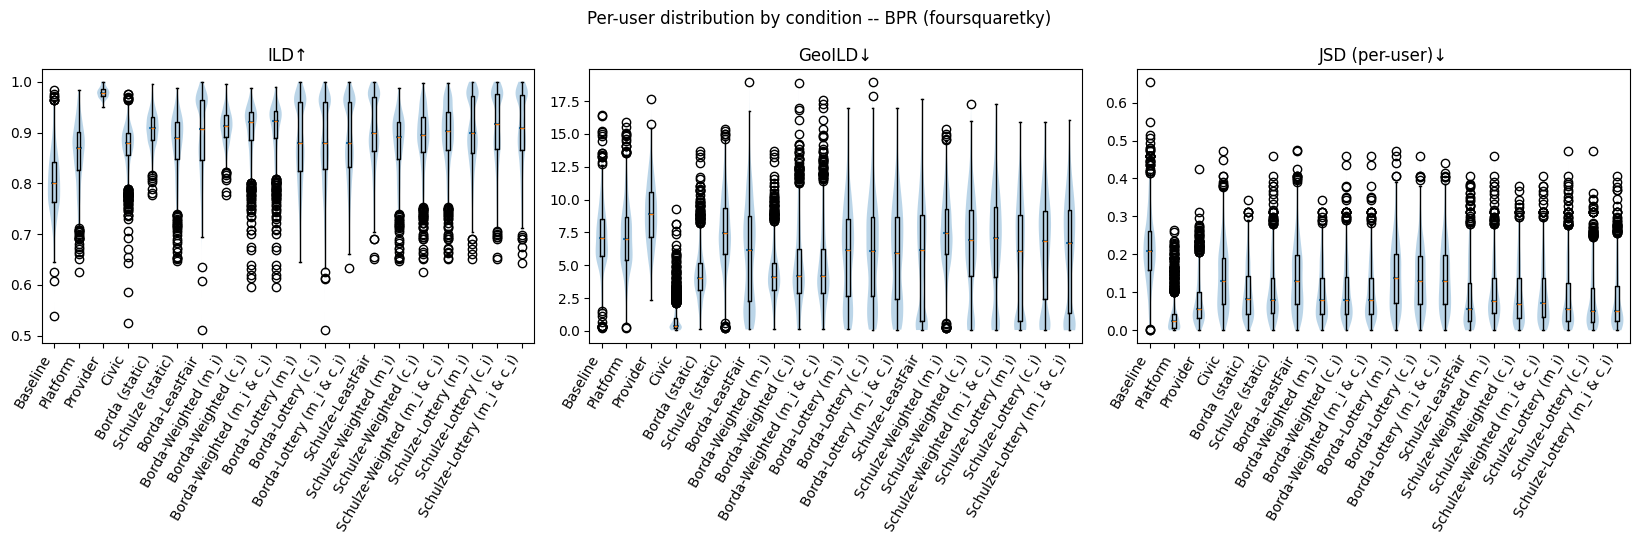

In [31]:
local_rename_metrics = {**rename_metrics, "jsd_user": "JSD (per-user)\u2193"}
plot_metrics = ["ild", "geo_ild", "jsd_user"]
plot_methods = [m for m in model_dirs[model_name] if m in group_scores[model_name]]
plot_methods = full_eval_methods + dynamic_methods


fig, axs = plt.subplots(1, len(plot_metrics), figsize=(5.5 * len(plot_metrics), 5.5))

for ax, metric in zip(axs, plot_metrics):
    data, labels = [], []
    for method_name in plot_methods:
        scores = group_scores[model_name][method_name].get(metric, {}).get("All", {})
        if not scores:
            continue
        data.append(list(scores.values()))
        labels.append(rename_methods.get(method_name, method_name))

    positions = range(1, len(labels) + 1)
    ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    ax.boxplot(data, positions=positions, widths=0.15, showfliers=True)
    ax.set_xticks(list(positions))
    ax.set_xticklabels(labels, rotation=60, ha="right")
    ax.set_title(local_rename_metrics.get(metric, metric))

fig.suptitle(f"Per-user distribution by condition -- {model_name} ({dataset})")
fig.tight_layout()

plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_statistics.png"), bbox_inches="tight")
plt.show()


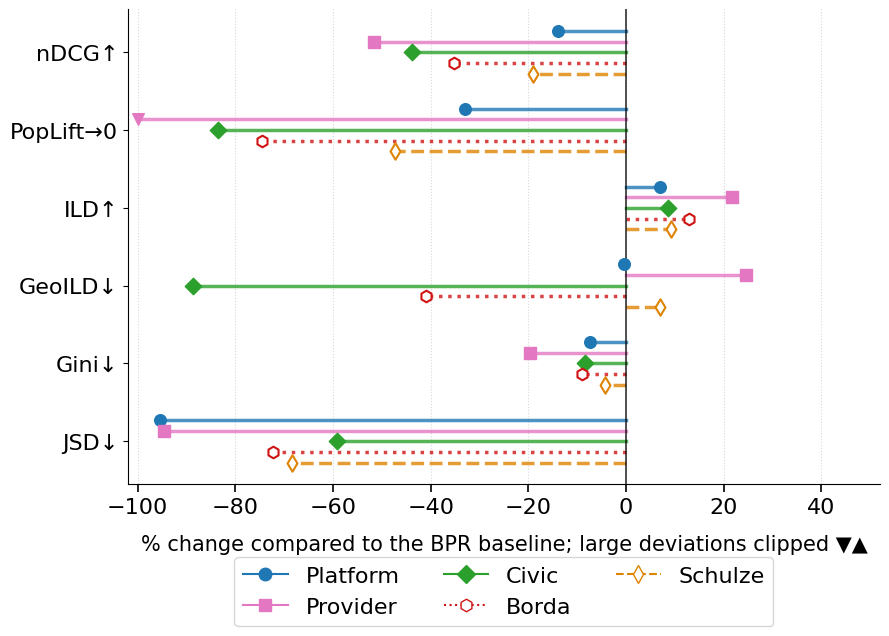

In [32]:
model_to_plot = models_for_recbole[0]
variant_styles = {
    "platform": {"color": "#1f77b4", "ls": "-", "marker": "o", "fill": "full", "label": "Platform"},
    "provider": {"color": "#e377c2", "ls": "-", "marker": "s", "fill": "fill", "label": "Provider"},
    "civic": {"color": "#2ca02c", "ls": "-", "marker": "D", "fill": "full", "label": "Civic"},
    "borda": {"color": "#d01414", "ls": ":", "marker": "h", "fill": "none", "label": "Borda"},
    "schulze": {"color": "#df8302", "ls": "--", "marker": "d", "fill": "none", "label": "Schulze"},

}

rows = []
baseline_data = filtered_results[model_to_plot]["baseline"]

# Enforce loop consistency by utilizing the explicit list ordering
methods_keys = [m for m in variant_styles.keys() if m in filtered_results[model_to_plot]]

for method in methods_keys:
    delta = {}
    for m in valid_metrics:
        base_val = baseline_data[m]["val"]
        curr_val = filtered_results[model_to_plot][method][m]["val"]
        delta[m] = ((curr_val - base_val) / abs(base_val)) * 100 if base_val != 0 else 0

    delta["method"] = method
    rows.append(delta)

rel_df = pd.DataFrame(rows).set_index("method")
metric_labels = [rename_metrics.get(m, m) for m in valid_metrics]
fig, ax = plt.subplots(figsize=(9, 6.5))
CLIP_low = 100
CLIP_high = 50
Y_SPACING = 0.4
y_pos = np.arange(len(valid_metrics)) * Y_SPACING
n_methods = len(methods_keys)

for i, method in enumerate(methods_keys):
    vals = rel_df.loc[method, valid_metrics].values
    style = variant_styles[method]
    
    color = style["color"]
    ls = style["ls"]
    m_type = style["marker"]

    offset = (i - n_methods / 2 + 0.5) * 0.055

    for j, val in enumerate(vals):
        y = y_pos[j] + offset
        clipped = np.clip(val, -CLIP_low, CLIP_high)
        final_marker = "^" if val > CLIP_high else ("v" if val < -CLIP_low else m_type)
        ax.plot([0, clipped], [y, y], color=color, linestyle=ls, lw=2.5, alpha=0.8)

        if style["fill"] == "none" and final_marker == m_type:
            ax.scatter(clipped, y, edgecolor=color, facecolor="white", s=70, zorder=3, marker=final_marker, lw=1.5)
        elif style["fill"] == "left" and final_marker == m_type:
            ax.scatter(clipped, y, s=70, zorder=3, marker=MarkerStyle(final_marker, fillstyle="left"), color=color)
        else:
            ax.scatter(clipped, y, color=color, s=70, zorder=3, marker=final_marker, alpha=1.0)

ax.axvline(0, color="black", lw=1.2, ls="-", alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(metric_labels, fontsize=16)
ax.invert_yaxis()

ax.set_xlabel("% change compared to the BPR baseline; large deviations clipped ▼▲", fontsize=15, labelpad=12)
ax.set_xlim(-CLIP_low-2, CLIP_high+2)
ax.tick_params(axis="x", labelsize=16, length=6, width=1.2)
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = []
for m in methods_keys:
    style = variant_styles[m]
    label_text = style["label"]

    if style["fill"] == "none":
        handle = mlines.Line2D([], [], color=style["color"], linestyle=style["ls"], 
                               marker=style["marker"], markerfacecolor="white", markeredgecolor=style["color"],
                               markersize=9, lw=1.5, label=label_text)
    elif style["fill"] == "left":
        handle = mlines.Line2D([], [], color=style["color"], linestyle=style["ls"], 
                               marker=style["marker"], markerfacecolor=style["color"], markeredgecolor=style["color"],
                               fillstyle="left", markersize=9, lw=1.5, label=label_text)
    else:
        handle = mlines.Line2D([], [], color=style["color"], linestyle=style["ls"], 
                               marker=style["marker"], markerfacecolor=style["color"],
                               markersize=9, lw=1.5, label=label_text)
    legend_handles.append(handle)

ax.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.13),
    frameon=True,
    fontsize=16,
)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_metrics_percentage_change.png"), bbox_inches="tight", dpi=300)
plt.show()

In [33]:
# Additional Config for a Relative Plot including the weighted experiments

# variant_styles_full_plot = {
#     "platform": {"color": "#1f77b4", "ls": "-", "marker": "o", "fill": "full", "label": "Platform"},
#     "provider": {"color": "#e377c2", "ls": "-", "marker": "s", "fill": "full", "label": "Provider"},
#     "civic": {"color": "#2ca02c", "ls": "-", "marker": "D", "fill": "full", "label": "Civic"},
    
#     "borda": {"color": "#d87192", "ls": "-", "marker": "h", "fill": "full", "label": "Borda"},
#     "schulze": {"color": "#df8302", "ls": "-", "marker": "d", "fill": "full", "label": "Schulze"},

#     "borda2baseline": {"color": "#7f7f7f", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-User"},
#     "borda2platform": {"color": "#1f77b4", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-Platform"},
#     "borda2provider": {"color": "#e377c2", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-Provider"},
#     "borda2civic": {"color": "#2ca02c", "ls": "--", "marker": "h", "fill": "none", "label": "Borda-Civic"},

#     "schulze2baseline": {"color": "#7f7f7f", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-User"},
#     "schulze2platform": {"color": "#1f77b4", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-Platform"},
#     "schulze2provider": {"color": "#e377c2", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-Provider"},
#     "schulze2civic": {"color": "#2ca02c", "ls": ":", "marker": "d", "fill": "full", "label": "Schulze-Civic"},

# }

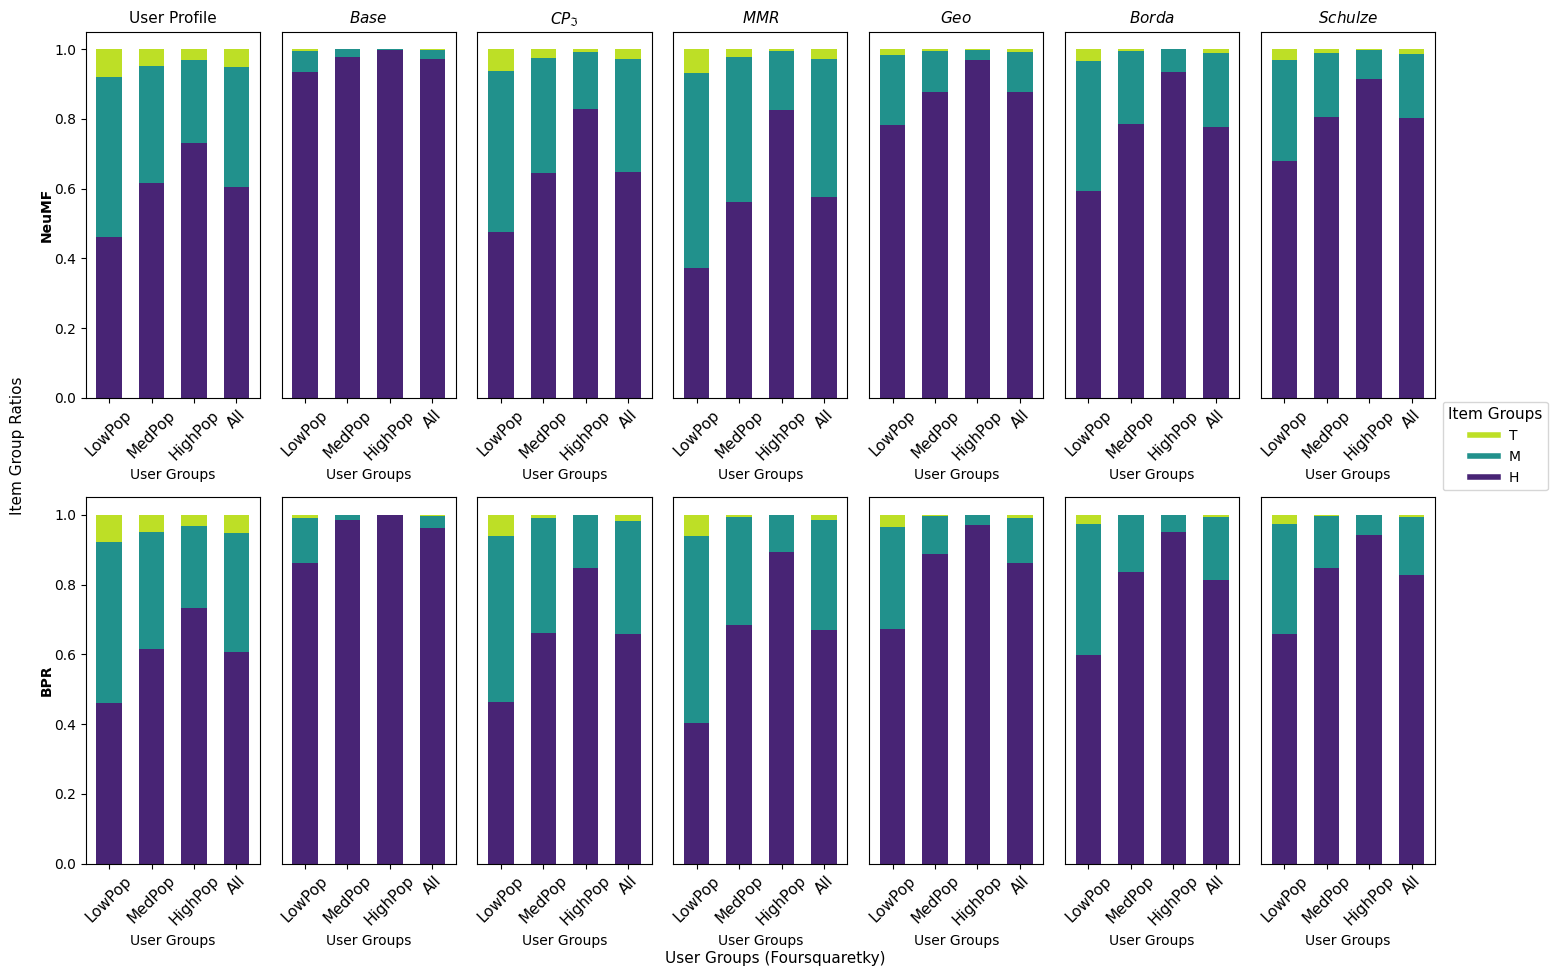

In [34]:
method_names_for_title = ["$Base$", "$CP_\Im$", "$MMR$", "$Geo$", "$Borda$", "$Schulze$"]

filtered_models = [
    (model_name, methods)
    for model_name, methods in model_dirs.items()
    if model_name in models_for_recbole
]

n_rows = len(filtered_models)
fig, axs = plt.subplots(n_rows, 7, figsize=(15, 5.5 * n_rows), squeeze=False)

for row, (model_name, methods) in enumerate(filtered_models):
    ax = axs[row, 0]
    plot_popularity_distribution(ax, ground_truth_distr, None)
    if row == 0:
        ax.set_title("User Profile", fontsize=11)
    ax.set_ylabel(model_name, fontsize=10, weight="bold", labelpad=0)

    col = 0
    for method_name, json_file in methods.items():
        if method_name in full_eval_methods:
            df = top_k_to_df(json_file, top_k_eval=top_k_eval)
            distr_df = create_pop_distributions(df, item_popularity, user_groups)

            ax = axs[row, col + 1]
            plot_popularity_distribution(ax, distr_df, None)
            if row == 0:
                ax.set_title(method_names_for_title[col], fontsize=11)
            col += 1

for ax in axs.flat:
    ax.set_xticks(range(4))
    ax.set_xticklabels(["LowPop", "MedPop", "HighPop", "All"], rotation=45, fontsize=11)

for row in range(n_rows):
    for ax in axs[row, 1:]:
        ax.set_yticks([])

fig.text(0.55, 0.03, f"User Groups ({dataset.capitalize()})", ha="center", fontsize=11)
fig.text(0.04, 0.5, "Item Group Ratios", va="center", rotation="vertical", fontsize=11)

handles = [plt.Line2D([0], [0], color=color, lw=4) for color in plt.cm.viridis([0.9, 0.5, 0.1])]
labels = ["T", "M", "H"]
fig.legend(handles, labels, title="Item Groups", loc="center right", bbox_to_anchor=(1.07, 0.5), ncol=1, title_fontsize=11)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.91])
os.makedirs(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_popularity_distribution_paper.png"), bbox_inches="tight")